In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [5]:
df=pd.read_csv(r"SP2.csv")
df

,Roll,Nationality,WT,AI,DSBDA,AVG,GRADE,PG
0,1,INDIA,72.0,72.0,74.0,72.666667,A,YES
1,2,JAPAN,70.0,69.0,40.0,59.666667,B,YES
2,3,INDIA,NaN,40.0,60.0,50.000000,C,NO
3,4,US,50.0,30.0,NaN,40.000000,D,YES
4,5,UK,51.0,52.0,53.0,52.000000,C,NO
5,6,INDIA,45.0,40.0,NaN,42.500000,D,YES
6,7,JAPAN,75.0,89.0,56.0,73.333333,A,YES
7,8,INDIA,50.0,47.0,56.0,51.000000,C,YES
8,9,US,50.0,NaN,60.0,55.000000,C,NO
9,10,UK,60.0,NaN,80.0,70.000000,A,YES


In [7]:
df.describe()

,Roll,WT,AI,DSBDA,AVG
count,18.000000,16.000000,14.000000,15.000000,18.000000
mean,9.500000,54.437500,50.785714,60.466667,55.259259
std,5.338539,11.792476,20.218722,14.831755,12.299001
min,1.000000,42.000000,15.000000,40.000000,33.333333
25%,5.250000,46.500000,40.000000,50.500000,49.666667
50%,9.500000,50.000000,49.000000,56.000000,51.500000
75%,13.750000,62.500000,65.750000,74.000000,64.416667
max,18.000000,75.000000,89.000000,85.000000,77.500000


In [9]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18 entries, 0 to 17
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Roll         18 non-null     int64  
 1   Nationality  18 non-null     object 
 2   WT           16 non-null     float64
 3   AI           14 non-null     float64
 4   DSBDA        15 non-null     float64
 5   AVG          18 non-null     float64
 6   GRADE        18 non-null     object 
 7   PG           18 non-null     object 
dtypes: float64(4), int64(1), object(3)
memory usage: 1.3+ KB


In [11]:
df.notnull()


,Roll,Nationality,WT,AI,DSBDA,AVG,GRADE,PG
0,True,True,True,True,True,True,True,True
1,True,True,True,True,True,True,True,True
2,True,True,False,True,True,True,True,True
3,True,True,True,True,False,True,True,True
4,True,True,True,True,True,True,True,True
5,True,True,True,True,False,True,True,True
6,True,True,True,True,True,True,True,True
7,True,True,True,True,True,True,True,True
8,True,True,True,False,True,True,True,True
9,True,True,True,False,True,True,True,True


In [13]:
df.dtypes

Roll             int64
Nationality     object
WT             float64
AI             float64
DSBDA          float64
AVG            float64
GRADE           object
PG              object
dtype: object

In [15]:
df.select_dtypes('object').apply(pd.Series.nunique, axis=0)

Nationality    4
GRADE          4
PG             2
dtype: int64

In [17]:
df.select_dtypes('float').apply(pd.Series.nunique, axis=0)

WT        9
AI       13
DSBDA     9
AVG      16
dtype: int64

In [19]:
categorical_F = df.select_dtypes(object)
categorical_F.describe()

,Nationality,GRADE,PG
count,18,18,18
unique,4,4,2
top,INDIA,C,YES
freq,9,8,12


In [21]:

categorical_F = df.select_dtypes(float)
categorical_F.describe()

,WT,AI,DSBDA,AVG
count,16.000000,14.000000,15.000000,18.000000
mean,54.437500,50.785714,60.466667,55.259259
std,11.792476,20.218722,14.831755,12.299001
min,42.000000,15.000000,40.000000,33.333333
25%,46.500000,40.000000,50.500000,49.666667
50%,50.000000,49.000000,56.000000,51.500000
75%,62.500000,65.750000,74.000000,64.416667
max,75.000000,89.000000,85.000000,77.500000


In [25]:
missing_values = ["Na", "na"]
df1 = pd.read_csv(r"SP2.csv", na_values =
missing_values)
df1

,Roll,Nationality,WT,AI,DSBDA,AVG,GRADE,PG
0,1,INDIA,72.0,72.0,74.0,72.666667,A,YES
1,2,JAPAN,70.0,69.0,40.0,59.666667,B,YES
2,3,INDIA,NaN,40.0,60.0,50.000000,C,NO
3,4,US,50.0,30.0,NaN,40.000000,D,YES
4,5,UK,51.0,52.0,53.0,52.000000,C,NO
5,6,INDIA,45.0,40.0,NaN,42.500000,D,YES
6,7,JAPAN,75.0,89.0,56.0,73.333333,A,YES
7,8,INDIA,50.0,47.0,56.0,51.000000,C,YES
8,9,US,50.0,NaN,60.0,55.000000,C,NO
9,10,UK,60.0,NaN,80.0,70.000000,A,YES


In [27]:
df.isnull().sum()

Roll           0
Nationality    0
WT             2
AI             4
DSBDA          3
AVG            0
GRADE          0
PG             0
dtype: int64

In [29]:
x=df["GRADE"].mode()
x

0    C
Name: GRADE, dtype: object

In [31]:
df["GRADE"].value_counts()

GRADE
C    8
A    4
B    3
D    3
Name: count, dtype: int64

In [33]:

df["WT"].mean()

54.4375

In [35]:
df["AI"].mean()

50.785714285714285

In [37]:
df["DSBDA"].mean()

60.46666666666667

In [50]:
t=df["WT"].mean()
df["WT"]=df["WT"].fillna(t)
df["WT"]

0     72.0000
1     70.0000
2     54.4375
3     50.0000
4     51.0000
5     45.0000
6     75.0000
7     50.0000
8     50.0000
9     60.0000
10    75.0000
11    45.0000
12    47.0000
13    47.0000
14    54.4375
15    45.0000
16    47.0000
17    42.0000
Name: WT, dtype: float64

In [52]:

df["WT"] = df["WT"].replace(np.nan,df["WT"].mean()) 
df["WT"]

0     72.0000
1     70.0000
2     54.4375
3     50.0000
4     51.0000
5     45.0000
6     75.0000
7     50.0000
8     50.0000
9     60.0000
10    75.0000
11    45.0000
12    47.0000
13    47.0000
14    54.4375
15    45.0000
16    47.0000
17    42.0000
Name: WT, dtype: float64

In [54]:
t=df["AI"].median()
df["AI"]=df["AI"].fillna(t)
df["AI"]


0     72.0
1     69.0
2     40.0
3     30.0
4     52.0
5     40.0
6     89.0
7     47.0
8     49.0
9     49.0
10    29.0
11    15.0
12    49.0
13    46.0
14    75.0
15    56.0
16    49.0
17    51.0
Name: AI, dtype: float64

In [56]:
t=df["DSBDA"].mode()
df["DSBDA"]=df["DSBDA"].fillna(t)
df["DSBDA"]

0     74.0
1     40.0
2     60.0
3      NaN
4     53.0
5      NaN
6     56.0
7     56.0
8     60.0
9     80.0
10    45.0
11    40.0
12    85.0
13    56.0
14    80.0
15    48.0
16     NaN
17    74.0
Name: DSBDA, dtype: float64

In [62]:
df["AVG"] = df["AVG"].fillna(df["AVG"].mean())
df["PG"] = df["PG"].fillna(method='ffill')

C:\Users\Victus\AppData\Local\Temp\ipykernel_10800\3185756516.py:2: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df["PG"] = df["PG"].fillna(method='ffill')


In [64]:
df.isnull().sum()

Roll           0
Nationality    0
WT             0
AI             0
DSBDA          3
AVG            0
GRADE          0
PG             0
dtype: int64

In [70]:

df.dropna()

df.dropna(how='all')

df.dropna(axis=1)

new_data = df.dropna(axis=0, how='any')
new_data


,Roll,Nationality,WT,AI,DSBDA,AVG,GRADE,PG
0,1,INDIA,72.0000,72.0,74.0,72.666667,A,YES
1,2,JAPAN,70.0000,69.0,40.0,59.666667,B,YES
2,3,INDIA,54.4375,40.0,60.0,50.000000,C,NO
4,5,UK,51.0000,52.0,53.0,52.000000,C,NO
6,7,JAPAN,75.0000,89.0,56.0,73.333333,A,YES
7,8,INDIA,50.0000,47.0,56.0,51.000000,C,YES
8,9,US,50.0000,49.0,60.0,55.000000,C,NO
9,10,UK,60.0000,49.0,80.0,70.000000,A,YES
10,11,INDIA,75.0000,29.0,45.0,49.666667,C,NO
11,12,JAPAN,45.0000,15.0,40.0,33.333333,D,YES


<Axes: >

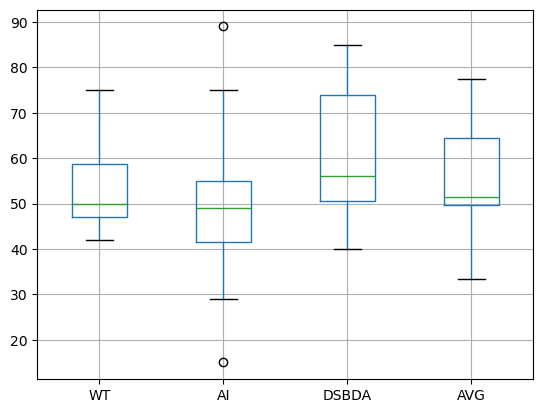

In [72]:

col = ['WT', 'AI' , 'DSBDA','AVG']
df.boxplot(col)

In [74]:
print(np.where(df['AI']>75))

(array([6], dtype=int64),)


In [76]:
print(np.where(df['AI']<30))

(array([10, 11], dtype=int64),)


In [78]:
print(np.where(df['WT']>70))

(array([ 0,  6, 10], dtype=int64),)


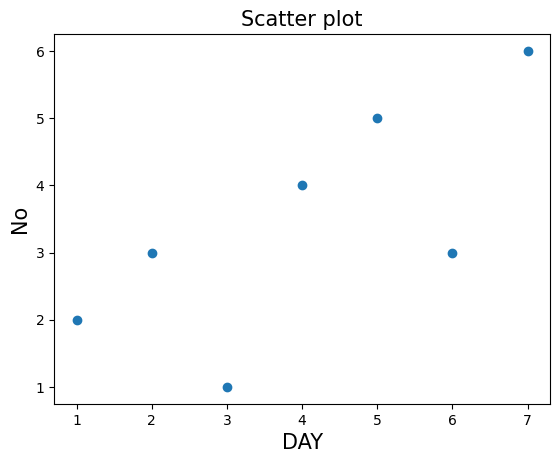

In [80]:

x=[1,2,3,4,5,6,7]
y=[2,3,1,4,5,3,6]
plt.scatter(x,y)
plt.title("Scatter plot",fontsize=15)
plt.xlabel("DAY",fontsize=15) 
plt.ylabel("No",fontsize=15)           
plt.show()

In [84]:
z=range(len(df["WT"]))

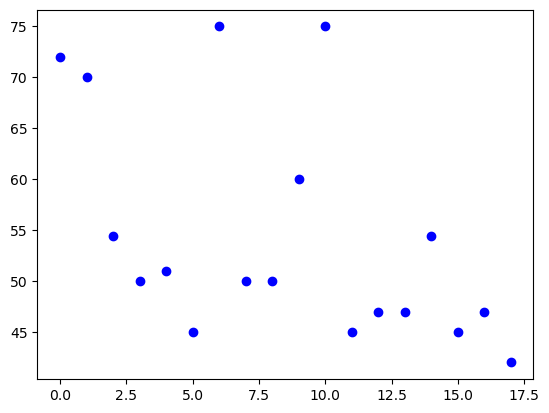

In [86]:
import matplotlib.pyplot as plt
 
x =z 
y=df["WT"]

 
plt.scatter(x,y,c ="blue")
 
# To show the plot
plt.show()

In [88]:

print(np.where((df['WT']<50) & (df['AI']>50)))

(array([15, 17], dtype=int64),)


In [90]:

df1=np.where((df['WT']<50) & (df['AI']>50))
print(df1)

(array([15, 17], dtype=int64),)


In [92]:
from scipy import stats
z = np.abs(stats.zscore(df['WT']))
print(z)

0     1.631443
1     1.445656
2     0.000000
3     0.412215
4     0.319322
5     0.876683
6     1.910124
7     0.412215
8     0.412215
9     0.516720
10    1.910124
11    0.876683
12    0.690896
13    0.690896
14    0.000000
15    0.876683
16    0.690896
17    1.155364
Name: WT, dtype: float64


In [94]:
threshold = 0.18
sample_outliers = np.where(z <threshold)
sample_outliers

(array([ 2, 14], dtype=int64),)

In [96]:
sorted_WT= sorted(df['WT'])
sorted_WT

[42.0,
 45.0,
 45.0,
 45.0,
 47.0,
 47.0,
 47.0,
 50.0,
 50.0,
 50.0,
 51.0,
 54.4375,
 54.4375,
 60.0,
 70.0,
 72.0,
 75.0,
 75.0]

In [102]:
q1 = np.percentile(sorted_WT, 25)
q3 = np.percentile(sorted_WT, 75)
print(q1,q3)

47.0 58.609375


In [106]:
IQR = q3 - q1
lwr_bound = q1 - (1.5 * IQR)
upr_bound = q3 + (1.5 * IQR)
print(lwr_bound, upr_bound)


29.5859375 76.0234375


In [112]:
r_outliers = []
for i in sorted_WT:
    if (i<lwr_bound or i>upr_bound):
        r_outliers.append(i)
print(r_outliers)

[]


In [110]:

new_df=df
for i in sample_outliers:
    new_df.drop(i,inplace=True)
new_df

,Roll,Nationality,WT,AI,DSBDA,AVG,GRADE,PG
0,1,INDIA,72.0,72.0,74.0,72.666667,A,YES
1,2,JAPAN,70.0,69.0,40.0,59.666667,B,YES
3,4,US,50.0,30.0,NaN,40.000000,D,YES
4,5,UK,51.0,52.0,53.0,52.000000,C,NO
5,6,INDIA,45.0,40.0,NaN,42.500000,D,YES
6,7,JAPAN,75.0,89.0,56.0,73.333333,A,YES
7,8,INDIA,50.0,47.0,56.0,51.000000,C,YES
8,9,US,50.0,49.0,60.0,55.000000,C,NO
9,10,UK,60.0,49.0,80.0,70.000000,A,YES
10,11,INDIA,75.0,29.0,45.0,49.666667,C,NO


In [114]:

new_df1=df
for i in r_outliers:
    new_df1.drop(i,inplace=True)
new_df1

,Roll,Nationality,WT,AI,DSBDA,AVG,GRADE,PG
0,1,INDIA,72.0,72.0,74.0,72.666667,A,YES
1,2,JAPAN,70.0,69.0,40.0,59.666667,B,YES
3,4,US,50.0,30.0,NaN,40.000000,D,YES
4,5,UK,51.0,52.0,53.0,52.000000,C,NO
5,6,INDIA,45.0,40.0,NaN,42.500000,D,YES
6,7,JAPAN,75.0,89.0,56.0,73.333333,A,YES
7,8,INDIA,50.0,47.0,56.0,51.000000,C,YES
8,9,US,50.0,49.0,60.0,55.000000,C,NO
9,10,UK,60.0,49.0,80.0,70.000000,A,YES
10,11,INDIA,75.0,29.0,45.0,49.666667,C,NO


In [116]:
new_df2=df
new_df2

,Roll,Nationality,WT,AI,DSBDA,AVG,GRADE,PG
0,1,INDIA,72.0,72.0,74.0,72.666667,A,YES
1,2,JAPAN,70.0,69.0,40.0,59.666667,B,YES
3,4,US,50.0,30.0,NaN,40.000000,D,YES
4,5,UK,51.0,52.0,53.0,52.000000,C,NO
5,6,INDIA,45.0,40.0,NaN,42.500000,D,YES
6,7,JAPAN,75.0,89.0,56.0,73.333333,A,YES
7,8,INDIA,50.0,47.0,56.0,51.000000,C,YES
8,9,US,50.0,49.0,60.0,55.000000,C,NO
9,10,UK,60.0,49.0,80.0,70.000000,A,YES
10,11,INDIA,75.0,29.0,45.0,49.666667,C,NO


In [118]:
ninetieth_percentile = np.percentile(new_df2['WT'], 80)
b = np.where(new_df2['WT']>ninetieth_percentile,
ninetieth_percentile, new_df2['WT'])
print("New array:",b)


New array: [70. 70. 50. 51. 45. 70. 50. 50. 60. 70. 45. 47. 47. 45. 47. 42.]


In [124]:
col = ['AI']
df.boxplot(col)

<Axes: >

In [126]:

mean=df["WT"].mean()
mean


54.4375

In [128]:

ndata=df
ndata

,Roll,Nationality,WT,AI,DSBDA,AVG,GRADE,PG
0,1,INDIA,72.0,72.0,74.0,72.666667,A,YES
1,2,JAPAN,70.0,69.0,40.0,59.666667,B,YES
3,4,US,50.0,30.0,NaN,40.000000,D,YES
4,5,UK,51.0,52.0,53.0,52.000000,C,NO
5,6,INDIA,45.0,40.0,NaN,42.500000,D,YES
6,7,JAPAN,75.0,89.0,56.0,73.333333,A,YES
7,8,INDIA,50.0,47.0,56.0,51.000000,C,YES
8,9,US,50.0,49.0,60.0,55.000000,C,NO
9,10,UK,60.0,49.0,80.0,70.000000,A,YES
10,11,INDIA,75.0,29.0,45.0,49.666667,C,NO


In [130]:
ndata['AI'] = ndata.loc[(ndata['AI']>upr_bound),'AI']=mean
ndata


,Roll,Nationality,WT,AI,DSBDA,AVG,GRADE,PG
0,1,INDIA,72.0,54.4375,74.0,72.666667,A,YES
1,2,JAPAN,70.0,54.4375,40.0,59.666667,B,YES
3,4,US,50.0,54.4375,NaN,40.000000,D,YES
4,5,UK,51.0,54.4375,53.0,52.000000,C,NO
5,6,INDIA,45.0,54.4375,NaN,42.500000,D,YES
6,7,JAPAN,75.0,54.4375,56.0,73.333333,A,YES
7,8,INDIA,50.0,54.4375,56.0,51.000000,C,YES
8,9,US,50.0,54.4375,60.0,55.000000,C,NO
9,10,UK,60.0,54.4375,80.0,70.000000,A,YES
10,11,INDIA,75.0,54.4375,45.0,49.666667,C,NO


In [132]:
ndata['AI'] = ndata.loc[(ndata['AI']>lwr_bound),'AI']=mean
ndata


,Roll,Nationality,WT,AI,DSBDA,AVG,GRADE,PG
0,1,INDIA,72.0,54.4375,74.0,72.666667,A,YES
1,2,JAPAN,70.0,54.4375,40.0,59.666667,B,YES
3,4,US,50.0,54.4375,NaN,40.000000,D,YES
4,5,UK,51.0,54.4375,53.0,52.000000,C,NO
5,6,INDIA,45.0,54.4375,NaN,42.500000,D,YES
6,7,JAPAN,75.0,54.4375,56.0,73.333333,A,YES
7,8,INDIA,50.0,54.4375,56.0,51.000000,C,YES
8,9,US,50.0,54.4375,60.0,55.000000,C,NO
9,10,UK,60.0,54.4375,80.0,70.000000,A,YES
10,11,INDIA,75.0,54.4375,45.0,49.666667,C,NO


In [134]:

col1 = ['AI']
ndata.boxplot(col1)

<Axes: >